# Michigan Traders — Module 2
# Pandas for Financial Data  ·  *ANSWER KEY*

**Series:** MAT Education · Foundations
**Level:** Intermediate (builds on Module 1 — NumPy for Quants)
**Format:** **Interactive** — every idea gets an explanation, a worked example, then a **`# TODO` for you**.

---

NumPy gave us fast arrays. But real market data has **labels**: every price belongs to a *date* and a *ticker*. **Pandas** is NumPy with labels — a `DataFrame` is a table whose rows are time-stamped and whose columns are named. That single idea makes time-series work (returns, resampling, rolling windows, aligning two assets by date) almost trivial.

This is the library QuantConnect's research environment hands you data in (`qb.history(...)` returns a pandas `DataFrame`), so fluency here pays off directly in Module 4. Take it slowly — read each explanation, run the example, understand the output, *then* do the exercise.

## How to use this notebook

Runs in a normal Jupyter kernel:

```bash
pip install pandas numpy matplotlib
```

For each topic: **explanation** → **worked example** (already run) → **✏️ Your turn** (`# TODO`) → **self-check** (run it; `✅ Correct!` = win).

> **Stuck?** The full worked answer key is the companion notebook **`02_Pandas_for_Financial_Data_SOLUTIONS.ipynb`** — try the TODO first, then check yourself against it.

### Setup

By convention pandas is imported as `pd` (and NumPy as `np`). The cell below builds a **synthetic but realistic** price table so the whole notebook is self-contained — no downloads, no API keys. It simulates 2 years of daily prices for three tickers (SPY, AAPL, TLT) using the same random-walk idea from Module 1, and stores them in a `DataFrame` whose **index is the trading date** and whose **columns are the tickers**. Read the comments, then run it.

In [1]:
import numpy as np
import pandas as pd
pd.set_option("display.precision", 4)

rng = np.random.default_rng(42)
dates = pd.bdate_range("2021-01-04", periods=504)   # 504 business days ~ 2 trading years
specs = {"SPY": (0.0004, 0.010), "AAPL": (0.0007, 0.018), "TLT": (0.0001, 0.007)}  # (drift, vol)

prices = pd.DataFrame(index=dates)
for ticker, (mu, sd) in specs.items():
    daily = rng.normal(mu, sd, len(dates))          # daily returns
    prices[ticker] = 100 * np.exp(np.cumsum(daily)) # compounded into a price path
prices.index.name = "date"

print("shape:", prices.shape, "(rows = trading days, columns = tickers)")
prices.head()       # a bare DataFrame at the end of a cell renders as a nice table

shape: (504, 3) (rows = trading days, columns = tickers)


,SPY,AAPL,TLT
date,,,
2021-01-04,100.3453,94.8701,100.5408
2021-01-05,99.3469,94.0123,100.8179
2021-01-06,100.1353,98.2675,99.9602
2021-01-07,101.1220,99.1091,100.9846
2021-01-08,99.2079,98.1845,100.6413


## 1. Series & DataFrame — NumPy with labels

Pandas has two core objects:

- A **`Series`** is a 1-D labeled array — think *one column* with an index. Selecting a single column from a DataFrame gives you a Series.
- A **`DataFrame`** is a 2-D table: several Series that share one **index** (the row labels). Here the index is the date, the columns are tickers.

In [2]:
spy = prices["SPY"]          # selecting one column returns a Series
print("type:", type(spy).__name__)
print("name:", spy.name)
print(spy.head(3))               # a Series prints as: index -> value

type: Series
name: SPY
date
2021-01-04    100.3453
2021-01-05     99.3469
2021-01-06    100.1353
Freq: B, Name: SPY, dtype: float64


Four attributes describe any DataFrame. You'll print these constantly while debugging:

- `.index` — the row labels (here, the `DatetimeIndex` of dates)
- `.columns` — the column labels (the tickers)
- `.values` — the underlying NumPy array (pandas is built *on* NumPy)
- `.dtypes` / `.shape` — element types and `(rows, cols)`

In [3]:
print("columns :", list(prices.columns))
print("index   :", prices.index[:3].date, "...")
print("shape   :", prices.shape)
print("values  :", type(prices.values).__name__, prices.values.shape)   # it's a NumPy array

columns : ['SPY', 'AAPL', 'TLT']
index   : [datetime.date(2021, 1, 4) datetime.date(2021, 1, 5)
 datetime.date(2021, 1, 6)] ...
shape   : (504, 3)
values  : ndarray (504, 3)


Three methods for a fast look at a dataset: **`.head(n)`** / **`.tail(n)`** show the first/last rows, and **`.describe()`** gives per-column summary statistics (count, mean, std, min, quartiles, max) — a one-line sanity check on any data you load.

In [4]:
prices.describe()

,SPY,AAPL,TLT
count,504.0000,504.0000,504.0000
mean,105.2434,87.5980,101.5976
std,6.7405,8.4788,3.5672
min,94.3150,69.5007,93.2520
25%,99.4733,81.4347,98.9479
50%,103.8059,88.2096,100.9772
75%,110.5657,93.0554,104.6421
max,121.2162,110.8417,109.8803


### ✏️ Your turn — grab a column

Select the **`AAPL`** column from `prices` into a variable `aapl`. (Selecting a single column returns a `Series`.)

In [5]:
aapl = prices["AAPL"]

In [6]:
assert aapl is not None, "Replace None with your code."
assert isinstance(aapl, pd.Series), f"Expected a Series, got {type(aapl).__name__}"
assert aapl.name == "AAPL" and len(aapl) == len(prices)
print("✅ Correct! AAPL is a Series of", len(aapl), "prices. Last:", round(aapl.iloc[-1], 2))

✅ Correct! AAPL is a Series of 504 prices. Last: 95.26


## 2. Selecting rows: `.iloc` (by position) vs `.loc` (by label)

This is the distinction that trips up every pandas beginner, so let's be precise. There are two ways to pick rows:

- **`.iloc[...]`** — by **integer position**, exactly like NumPy. `prices.iloc[0]` is the first row, `prices.iloc[-1]` the last, `prices.iloc[:5]` the first five.
- **`.loc[...]`** — by **label**. Because our labels are dates, `prices.loc["2021-01-04"]` selects that date's row. `prices.loc[:, "SPY"]` selects a column by name.

Start with `iloc` — pure position.

In [7]:
print("first row, prices.iloc[0]:")
print(prices.iloc[0])               # a single row comes back as a Series, indexed by the columns
print("\nfirst 3 closes of SPY via iloc[:3]:")
print(prices.iloc[:3]["SPY"].round(2).tolist())

first row, prices.iloc[0]:
SPY     100.3453
AAPL     94.8701
TLT     100.5408
Name: 2021-01-04 00:00:00, dtype: float64

first 3 closes of SPY via iloc[:3]:
[100.35, 99.35, 100.14]


Now **`.loc`** — by label. Note a subtle but important difference from Python slicing: **label slices are *inclusive* of the end label**. And a single row (whether via `loc` or `iloc`) is returned as a `Series` indexed by the column names.

In [8]:
print("row for a specific date, prices.loc['2021-01-04']:")
print(prices.loc["2021-01-04"])
print("\nwhole SPY column via prices.loc[:, 'SPY'] (first 3):")
print(prices.loc[:, "SPY"].head(3).round(2).tolist())

row for a specific date, prices.loc['2021-01-04']:
SPY     100.3453
AAPL     94.8701
TLT     100.5408
Name: 2021-01-04 00:00:00, dtype: float64

whole SPY column via prices.loc[:, 'SPY'] (first 3):
[100.35, 99.35, 100.14]


### ✏️ Your turn — latest prices

Get the **most recent day's** prices (the last row of `prices`) into `latest`. Use position-based indexing.

In [9]:
latest = prices.iloc[-1]

In [10]:
assert latest is not None, "Replace None with your code."
assert isinstance(latest, pd.Series)
assert list(latest.index) == list(prices.columns), "A row is indexed by the column names."
assert latest.equals(prices.iloc[-1])
print("✅ Correct! latest prices:", latest.round(2).to_dict())

✅ Correct! latest prices: {'SPY': 114.61, 'AAPL': 95.26, 'TLT': 104.67}


## 3. The DatetimeIndex — time-series superpowers

Because the index is made of dates (a `DatetimeIndex`), pandas lets you slice by **time strings**. This is one of the biggest day-to-day conveniences in quant work.

- `prices.loc["2022"]` — every row in 2022
- `prices.loc["2021-06":"2021-09"]` — a date *range* (inclusive of both ends)

In [11]:
print("rows in all of 2022      :", len(prices.loc["2022"]))
print("rows from Jun-Sep 2021    :", len(prices.loc["2021-06":"2021-09"]))

rows in all of 2022      : 244
rows from Jun-Sep 2021    : 88


The index also exposes the parts of each date as arrays — `.year`, `.month`, `.day`, `.dayofweek` (0 = Monday … 4 = Friday). These are handy for grouping (§7) or filtering by calendar.

In [12]:
print("year of first 3 rows     :", list(prices.index[:3].year))
print("day-of-week of first 5 rows:", list(prices.index[:5].dayofweek), "(0=Mon)")

year of first 3 rows     : [2021, 2021, 2021]
day-of-week of first 5 rows: [0, 1, 2, 3, 4] (0=Mon)


### ✏️ Your turn — slice a year

Select **all rows from 2022** into `prices_2022` using label-based time slicing.

In [13]:
prices_2022 = prices.loc["2022"]

In [14]:
assert prices_2022 is not None, "Replace None with your code."
assert (prices_2022.index.year == 2022).all(), "Some rows aren't in 2022."
assert prices_2022.equals(prices.loc["2022"])
print("✅ Correct!", len(prices_2022), "trading days in 2022.")

✅ Correct! 244 trading days in 2022.


## 4. Returns: `pct_change`, `shift`, and the equity curve

Prices aren't directly comparable across assets; **returns** are. Pandas makes the conversion a one-liner.

**`pct_change()`** computes the simple return of each row vs the previous row: `P_today / P_yesterday - 1`. The very first row has no "previous," so it comes back as `NaN` — we drop it with `.dropna()`.

In [15]:
rets = prices.pct_change().dropna()    # daily simple returns; drop the first NaN row
print("daily returns (head):")
rets.head(3)

daily returns (head):


,SPY,AAPL,TLT
date,,,
2021-01-05,-0.0100,-0.0090,0.0028
2021-01-06,0.0079,0.0453,-0.0085
2021-01-07,0.0099,0.0086,0.0102


**`shift(1)`** moves every value *down* by one row — so `prices.shift(1)` is "yesterday's price, lined up against today." This is the building block for log returns, and (crucially) for **avoiding lookahead bias**: when you trade, you act on *yesterday's* signal, never today's not-yet-known close.

A **log return** is `ln(P_today / P_yesterday)`, which we can write directly with `shift`.

In [16]:
print("price vs shifted price (SPY, first 3 rows):")
print(pd.DataFrame({"price": prices["SPY"], "yesterday": prices["SPY"].shift(1)}).head(3))

log_rets_demo = np.log(prices / prices.shift(1)).dropna()
print("\nlog returns (head):")
print(log_rets_demo.head(2).round(4))

price vs shifted price (SPY, first 3 rows):
               price  yesterday
date                           
2021-01-04  100.3453        NaN
2021-01-05   99.3469   100.3453
2021-01-06  100.1353    99.3469

log returns (head):
               SPY    AAPL     TLT
date                              
2021-01-05 -0.0100 -0.0091  0.0028
2021-01-06  0.0079  0.0443 -0.0085


**The equity curve** — growth of \$1 — comes from *compounding* the returns: `(1 + rets).cumprod()`. `cumprod` is the cumulative product, so each day multiplies in that day's growth factor.

In [17]:
equity = (1 + rets).cumprod()
print("final value of $1 invested in each asset:")
print(equity.iloc[-1].round(3).to_dict())

final value of $1 invested in each asset:
{'SPY': 1.142, 'AAPL': 1.004, 'TLT': 1.041}


And because a `DataFrame` knows how to plot itself, visualizing is one call. Here we **normalize** each price series to start at 1 (`prices / prices.iloc[0]`) so the three assets are comparable on one chart.

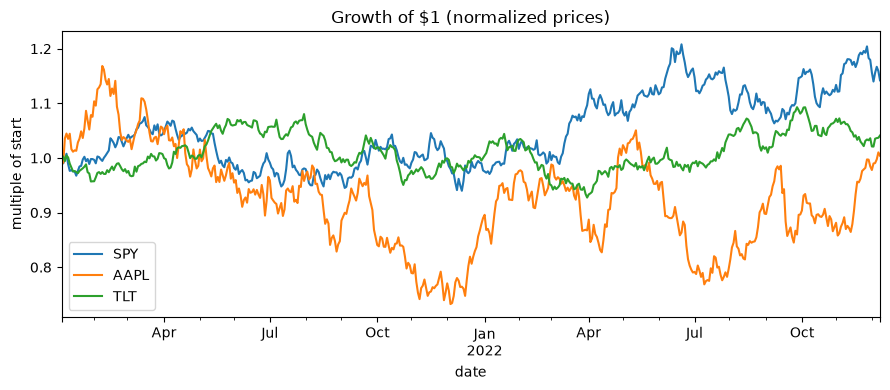

In [18]:
import matplotlib.pyplot as plt
(prices / prices.iloc[0]).plot(figsize=(9, 4), title="Growth of $1 (normalized prices)")
plt.ylabel("multiple of start"); plt.tight_layout(); plt.show()

### ✏️ Your turn — log returns

Compute **log returns** of `prices` into `log_rets` using `np.log` and `.shift(1)`, then drop the first `NaN` row. Shape should be `(503, 3)`.

In [19]:
log_rets = np.log(prices / prices.shift(1)).dropna()

In [20]:
assert log_rets is not None, "Replace None with your code."
assert log_rets.shape == (503, 3), f"Expected (503, 3), got {log_rets.shape}"
ref = np.log(prices / prices.shift(1)).dropna()
assert np.allclose(log_rets.values, ref.values), "Values don't match log returns."
print("✅ Correct! log returns head:\n", log_rets.head(2).round(4))

✅ Correct! log returns head:
                SPY    AAPL     TLT
date                              
2021-01-05 -0.0100 -0.0091  0.0028
2021-01-06  0.0079  0.0443 -0.0085


## 5. Resampling — change the time frequency

**`resample`** is like `groupby` but for time: it buckets rows into calendar periods (weeks, months, years) so you can aggregate each bucket. You pick a **frequency alias** and an aggregation.

Common aliases: `"ME"` = month-**end**, `"W"` = weekly, `"YE"` = year-end. Common aggregations: `.last()` (the closing price of the period), `.sum()` (e.g. summing returns), `.agg("ohlc")` (open/high/low/close bars).

> **pandas 3.0 note:** the month-end alias is **`"ME"`** — the old `"M"` was removed.

In [21]:
monthly = prices.resample("ME").last()   # the last price in each month
print("month-end prices (tail):")
monthly.tail(3)

month-end prices (tail):


,SPY,AAPL,TLT
date,,,
2022-10-31,112.5145,82.8616,107.1581
2022-11-30,118.3443,93.4098,104.1691
2022-12-31,114.6071,95.2627,104.6670


From month-end prices you get **month-over-month returns** the same way as daily — `pct_change`. Resampling to a coarser frequency is how you study a strategy on weekly or monthly bars instead of noisy daily data.

In [22]:
monthly_ret = monthly.pct_change().dropna()
print("number of months:", len(monthly))
print("monthly SPY returns (last 3):", monthly_ret["SPY"].tail(3).round(4).tolist())

number of months: 24
monthly SPY returns (last 3): [-0.0228, 0.0518, -0.0316]


### ✏️ Your turn — monthly prices

Resample `prices` to **month-end** values (last observation each month) into `monthly`. You should get ~24 rows.

In [23]:
monthly = prices.resample("ME").last()

In [24]:
assert monthly is not None, "Replace None with your code."
assert monthly.equals(prices.resample("ME").last()), "Use resample('ME').last()."
assert 23 <= len(monthly) <= 25, f"Expected ~24 months, got {len(monthly)}"
print("✅ Correct!", len(monthly), "month-end rows.")

✅ Correct! 24 month-end rows.


## 6. Rolling windows — moving averages, the easy way

Remember how awkward a moving average was in raw NumPy? In pandas it's one call. **`series.rolling(window)`** creates a sliding window of `window` rows, and you aggregate it — `.mean()`, `.std()`, etc. The first `window - 1` values are `NaN` because there isn't enough history yet to fill the window.

Rolling operations are the raw material of signals: moving averages, rolling volatility, Bollinger bands, rolling z-scores.

In [25]:
spy = prices["SPY"]
ma20 = spy.rolling(20).mean()        # 20-day moving average
print("first 19 values are NaN:", ma20.head(20).isna().sum(), "of the first 20")
print("latest 20-day MA:", round(ma20.iloc[-1], 2), "| latest price:", round(spy.iloc[-1], 2))

first 19 values are NaN: 19 of the first 20
latest 20-day MA: 117.87 | latest price: 114.61


Swap the aggregation and you get a different signal. A **rolling standard deviation** of returns is a *rolling volatility* — a live estimate of how risky the asset is right now (annualized with √252, just like Module 1).

In [26]:
roll_vol = rets["SPY"].rolling(20).std() * np.sqrt(252)
print("latest 20-day annualized vol:", round(roll_vol.iloc[-1], 3))

latest 20-day annualized vol: 0.158


### ✏️ Your turn — 50-day moving average

Compute the **50-day moving average** of SPY (`prices["SPY"]`) into `ma50`. The first 49 entries should be `NaN`, and `ma50.iloc[49]` should equal the mean of the first 50 prices.

In [27]:
ma50 = prices["SPY"].rolling(50).mean()

In [28]:
assert ma50 is not None, "Replace None with your code."
assert ma50.iloc[:49].isna().all(), "First 49 should be NaN (not enough history)."
assert np.isclose(ma50.iloc[49], prices["SPY"].iloc[:50].mean()), "Value at row 49 should be the mean of the first 50."
print("✅ Correct! 50-day MA ready. Latest:", round(ma50.iloc[-1], 2))

✅ Correct! 50-day MA ready. Latest: 115.51


## 7. `groupby` — split, apply, combine

`groupby` follows a three-step pattern: **split** the rows into groups by some key, **apply** an aggregation to each group, **combine** the results into one object. Paired with the DatetimeIndex, you can answer calendar questions like "what's the average return on each weekday?"

Here the grouping key is `rets.index.dayofweek` (0 = Monday … 4 = Friday), and we average the SPY return within each weekday.

In [29]:
by_dow = rets["SPY"].groupby(rets.index.dayofweek).mean()
print("avg SPY return by weekday (in basis points, 0=Mon):")
print((by_dow * 1e4).round(2).rename("bps").to_string())

avg SPY return by weekday (in basis points, 0=Mon):
date
0    2.53
1    2.86
2    5.85
3    4.04
4    0.21


### ✏️ Your turn — returns by weekday

Using the canonical `rets`, compute the **average AAPL daily return for each weekday** into `by_weekday` (a Series indexed 0–4). Group by `rets.index.dayofweek`.

In [30]:
by_weekday = rets["AAPL"].groupby(rets.index.dayofweek).mean()

In [31]:
assert by_weekday is not None, "Replace None with your code."
ref = rets["AAPL"].groupby(rets.index.dayofweek).mean()
assert len(by_weekday) == 5, f"Expected 5 weekdays, got {len(by_weekday)}"
assert np.allclose(by_weekday.values, ref.values)
print("✅ Correct! AAPL avg return by weekday (bps):", (by_weekday * 1e4).round(2).tolist())

✅ Correct! AAPL avg return by weekday (bps): [-29.38, 7.23, 22.61, 28.51, -20.96]


## 8. Multiple assets — correlation in one call

With returns for several assets sitting in one `DataFrame`, cross-asset analysis is trivial. **`rets.corr()`** returns the full correlation matrix — every pairwise correlation at once. This is the heart of diversification (Module 1's covariance idea) and of pairs research (Module 7): assets that move together can't diversify each other; pairs that move together are candidates for mean-reversion trades.

In [32]:
corr_demo = rets.corr()
print("correlation of daily returns:")
corr_demo.round(2)

correlation of daily returns:


,SPY,AAPL,TLT
SPY,1.00,-0.02,-0.01
AAPL,-0.02,1.00,0.02
TLT,-0.01,0.02,1.00


### ✏️ Your turn — correlation matrix

Compute the **correlation matrix** of the canonical `rets` DataFrame into `corr`. It should be 3×3 with 1.0 on the diagonal.

In [33]:
corr = rets.corr()

In [34]:
assert corr is not None, "Replace None with your code."
assert corr.shape == (3, 3), f"Expected (3, 3), got {corr.shape}"
assert np.allclose(np.diag(corr.values), 1.0), "Diagonal must be 1.0."
assert np.allclose(corr.values, corr.values.T), "Correlation matrices are symmetric."
print("✅ Correct! SPY/AAPL corr =", round(corr.loc["SPY", "AAPL"], 2))

✅ Correct! SPY/AAPL corr = -0.02


## 9. Alignment & missing data — the feature that prevents bugs

Here is pandas' quiet superpower: it **auto-aligns on the index** before doing arithmetic. If you add two Series with different dates, pandas matches them up *by label* and inserts `NaN` wherever one is missing — so you can never accidentally add Monday's price to Tuesday's.

Watch the `NaN`s appear at the non-overlapping ends:

In [35]:
a = pd.Series([1, 2, 3], index=pd.to_datetime(["2022-01-03", "2022-01-04", "2022-01-05"]))
b = pd.Series([10, 20, 30], index=pd.to_datetime(["2022-01-04", "2022-01-05", "2022-01-06"]))
print("a + b (aligned by date):")
print(a + b)

a + b (aligned by date):
2022-01-03     NaN
2022-01-04    12.0
2022-01-05    23.0
2022-01-06     NaN
dtype: float64


You handle the resulting gaps with a small toolkit: **`.dropna()`** removes missing rows (keeps only the overlap), **`.fillna(value)`** fills them, **`.reindex(...)`** conforms a Series to a new index, and **`pd.concat([...], axis=1)`** glues columns together aligning on the index.

In [36]:
print("keep only dates present in BOTH a and b:")
print((a + b).dropna())

keep only dates present in BOTH a and b:
2022-01-04    12.0
2022-01-05    23.0
dtype: float64


### ✏️ Your turn — align two series

Two Series `x` and `y` cover overlapping-but-different business days. Compute `x + y` and keep **only the dates present in both** (drop the `NaN`s) into `combined`. How many dates overlap?

In [37]:
x = pd.Series(1.0, index=pd.bdate_range("2022-01-03", periods=10))
y = pd.Series(2.0, index=pd.bdate_range("2022-01-10", periods=10))
combined = (x + y).dropna()

In [38]:
assert combined is not None, "Replace None with your code."
assert len(combined) == 5, f"Expected 5 overlapping dates, got {len(combined)}"
assert (combined == 3.0).all(), "Overlap values should be 1 + 2 = 3."
print("✅ Correct!", len(combined), "overlapping business days, each =", combined.iloc[0])

✅ Correct! 5 overlapping business days, each = 3.0


## \U0001f3c1 Mini-challenge: a reusable helper

Bundle the workflow into a function you'll actually reuse in research notebooks. It should take a price `DataFrame` and return one Sharpe ratio per column — combining `pct_change`, the per-column `mean`/`std`, and the √252 annualization.

### ✏️ Your turn — Sharpe per asset

Write `annualized_sharpe(prices_df)` that takes a price `DataFrame` and returns a **`Series`** of the annualized Sharpe ratio (rf = 0) for **each column**. Steps: prices → `pct_change().dropna()` → `mean / std * sqrt(252)`.

In [39]:
def annualized_sharpe(prices_df):
    r = prices_df.pct_change().dropna()
    return r.mean() / r.std() * np.sqrt(252)

In [40]:
res = annualized_sharpe(prices)
assert res is not None, "Return a value, not None."
assert isinstance(res, pd.Series), "Should return a Series (one Sharpe per column)."
assert list(res.index) == list(prices.columns), "Index should be the tickers."
_r = prices.pct_change().dropna()
expected = _r.mean() / _r.std() * np.sqrt(252)
assert np.allclose(res.values, expected.values)
print("✅ Correct! annualized Sharpe per asset:", res.round(2).to_dict())

✅ Correct! annualized Sharpe per asset: {'SPY': 0.51, 'AAPL': 0.15, 'TLT': 0.23}


## Cheat sheet

| Task | Pandas |
|---|---|
| Column / row | `df["SPY"]` (Series) · `df.iloc[0]` (by position) · `df.loc["2022-01-04"]` (by label) |
| Time slice | `df.loc["2022"]` · `df.loc["2021-06":"2021-09"]` |
| Index parts | `df.index.year`, `.month`, `.dayofweek` |
| Returns | `df.pct_change()` · `np.log(df / df.shift(1))` · `(1+r).cumprod()` |
| Resample | `df.resample("ME").last()` · `"W"` · `.agg("ohlc")` |
| Rolling | `s.rolling(20).mean()` · `.rolling(20).std()` |
| Group | `df.groupby(key).mean()` · `df.groupby(df.index.dayofweek)` |
| Cross-asset | `rets.corr()` · `rets.cov()` |
| Missing / align | `.dropna()` · `.fillna(...)` · `.reindex(...)` · auto-align on `+` |
| Plot | `df.plot()` (needs matplotlib) |

**Mental model:** a `DataFrame` is labeled NumPy. Operations align on the **index** first — that's what makes time-series safe.

## Stretch goals (bring to the next meeting)

1. Add **Bollinger Bands** to SPY: 20-day MA ± 2× 20-day rolling std. Plot price + bands.
2. Build a **monthly returns table**: month-end returns reshaped to year × month.
3. Compute each asset's **rolling 60-day correlation** with SPY (`s.rolling(60).corr(other)`).
4. Resample to weekly **OHLC** bars with `prices["SPY"].resample("W").agg("ohlc")`.

---

### What's next
**Notebook 03 — The 5 Pillars of a QuantConnect Algorithm:** we leave the local kernel and move to LEAN. Everything you just learned returns in **Notebook 04 (the Research Environment)**, where `qb.history(...)` hands you exactly these pandas `DataFrame`s.

**Pandas docs:** [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html) · [Time series](https://pandas.pydata.org/docs/user_guide/timeseries.html) · [Group by](https://pandas.pydata.org/docs/user_guide/groupby.html)

*MAT Education · Foundations · Module 2.*